# Visualisation des Données  (Avant Transformation Airflow)

Ce notebook contient le code nécessaire pour explorer et visualiser les datasets bruts avant qu'ils ne soient fusionnés et transformés par les pipelines Airflow (Medallion & Valorisation).

In [18]:
import os
import yaml
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import os, cv2, yaml, random
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

In [4]:
STATION_DIR = os.path.join("../", "data", "raw", "station")
FARM_DIR = os.path.join("../", "data", "raw", "farme")
BRONZE_DIR = os.path.join("../", "data", "bronze")
SILVER_DIR = os.path.join("../", "data", "silver")


In [5]:
path = "../data/"
print(os.listdir(BRONZE_DIR ))

['roboflow', 'plant-doc']


### Les classes

In [6]:
def plot_class_distribution(DATASET_PATH):
    with open(f"{DATASET_PATH}/data.yaml", 'r') as f:
        data = yaml.safe_load(f)
    
    names = data['names']
    nc = data['nc']
    
   
    df = pd.DataFrame({'Classes': names})
    print(f"Nombre total de classes : {nc}")
    print(df)
    print("\n")

In [27]:
def analyze_classes(dataset_path, split='train'):
    yaml_path = os.path.join(dataset_path, 'data.yaml')
    with open(yaml_path, 'r') as f:
        data_yaml = yaml.safe_load(f)
    
    class_names = data_yaml['names']
    label_dir = os.path.join(dataset_path, split, 'labels')
    
    class_counts = Counter()
    if os.path.exists(label_dir):
        label_files = [f for f in os.listdir(label_dir) if f.endswith('.txt')]
        for label_file in tqdm(label_files, desc=f"Analyzing {split} labels"):
            with open(os.path.join(label_dir, label_file), 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if not parts: # Skip empty lines
                        continue
                    try:
                        class_id = int(parts[0])
                        class_counts[class_id] += 1
                    except (ValueError, IndexError):
                        # Handle malformed lines gracefully
                        continue
    
    # Map IDs to names, handling cases where class_id might be out of yaml bounds
    named_counts = {}
    for i, count in class_counts.items():
        if i < len(class_names):
            named_counts[class_names[i]] = count
        else:
            named_counts[f"Unknown_{i}"] = count
            
    return named_counts


In [8]:

def plot_images(dataset_path, split='val', num_samples=4):
    yaml_path = os.path.join(dataset_path, "data.yaml")
    if not os.path.exists(yaml_path):
        print(f"Erreur : data.yaml non trouvé dans {dataset_path}")
        return

    with open(yaml_path, 'r') as f:
        config = yaml.safe_load(f)
    
    names = config['names']
    img_dir = os.path.join(dataset_path, split, "images")
    lbl_dir = os.path.join(dataset_path, split, "labels")
    
    if not os.path.exists(img_dir):
        print(f"Erreur : Dossier d'images non trouvé : {img_dir}")
        return

    images = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    samples = random.sample(images, min(len(images), num_samples))
    
    plt.figure(figsize=(15, 10))
    for i, img_name in enumerate(samples):
        img_path = os.path.join(img_dir, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape
        
        found_labels = set()
        lbl_path = os.path.join(lbl_dir, img_name.rsplit('.', 1)[0] + ".txt")
        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                for line in f:
                    parts = list(map(float, line.split()))
                    if not parts: continue
                    
                    cls = int(parts[0])
                    coords = parts[1:]
                    found_labels.add(names[cls])
                    
                    # Détection auto du format (Box vs Polygon)
                    if len(coords) == 4:
                        # YOLO Standard: [x_center, y_center, w, h]
                        x, y, bw, bh = coords
                        x1, y1 = int((x - bw/2) * w), int((y - bh/2) * h)
                        x2, y2 = int((x + bw/2) * w), int((y + bh/2) * h)
                    elif len(coords) > 4:
                        xs = coords[0::2]
                        ys = coords[1::2]
                        x1, y1 = int(min(xs) * w), int(min(ys) * h)
                        x2, y2 = int(max(xs) * w), int(max(ys) * h)
                    else: continue
                        
                    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
                    cv2.putText(img, names[cls], (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
        plt.subplot(2, 2, i+1)
        plt.imshow(img)
        plt.title(f"{img_name}\nLabels: {', '.join(found_labels)}", fontsize=10)
        plt.axis('off')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

### Visualization dataset des plantes 

In [9]:
PROD_DS = os.path.join(SILVER_DIR, "detection_maladies_plantes")


In [10]:
print("********Classes de plantDoc dataset ************")
plot_class_distribution(DATASET_PATH=PROD_DS )



********Classes de plantDoc dataset ************
Nombre total de classes : 18
                                 Classes
0                       Corn leaf blight
1                         Corn rust leaf
2                Tomato leaf late blight
3                       Tomato mold leaf
4               Tomato leaf yellow virus
5                         Blueberry leaf
6               Tomato leaf mosaic virus
7             Tomato leaf bacterial spot
8             Squash Powdery mildew leaf
9                    Corn Gray leaf spot
10              Tomato Early blight leaf
11             Tomato Septoria leaf spot
12                           Tomato leaf
13                 Bell_pepper leaf spot
14                      Bell_pepper leaf
15  Tomato two spotted spider mites leaf
16                 Nutrient Deficiencies
17                            White bugs




In [28]:
analyze_classes(PROD_DS)

Analyzing train labels:  18%|█▊        | 535/2958 [00:00<00:00, 5342.26it/s]

Analyzing train labels: 100%|██████████| 2958/2958 [00:00<00:00, 3806.26it/s]


{'Tomato mold leaf': 275,
 'Tomato leaf bacterial spot': 3610,
 'Corn rust leaf': 116,
 'Tomato leaf late blight': 206,
 'Squash Powdery mildew leaf': 248,
 'Nutrient Deficiencies': 384,
 'Tomato leaf yellow virus': 787,
 'Bell_pepper leaf': 327,
 'Blueberry leaf': 827,
 'White bugs': 66,
 'Tomato Early blight leaf': 195,
 'Tomato leaf': 369,
 'Tomato leaf mosaic virus': 225,
 'Corn leaf blight': 356,
 'Bell_pepper leaf spot': 429,
 'Tomato Septoria leaf spot': 403,
 'Corn Gray leaf spot': 74,
 'Tomato two spotted spider mites leaf': 2}

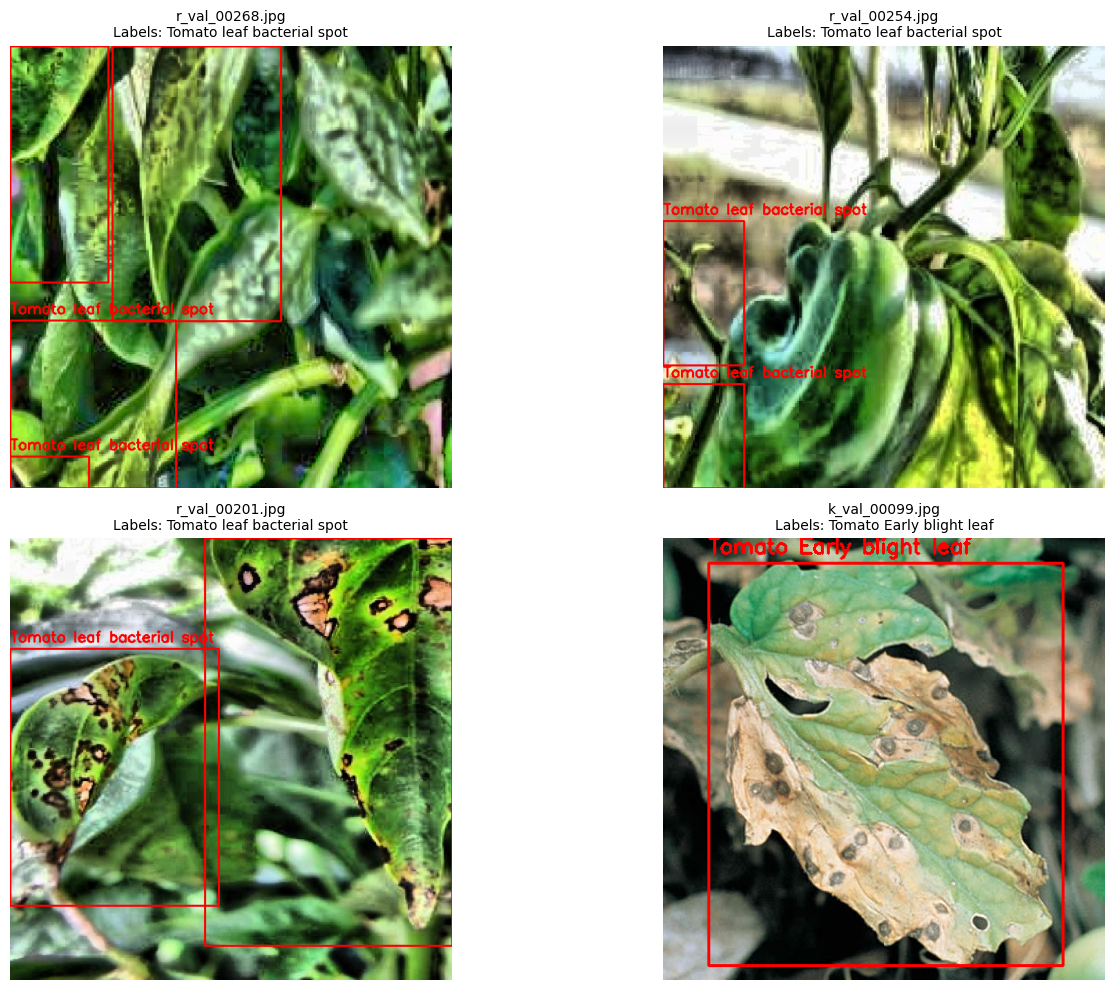

In [12]:
plot_images(PROD_DS, split='val')

### Visualization dataset des fruits t vegetables

In [21]:
VALOR_DS = os.path.join(SILVER_DIR, "fruits-vegetables-disease-detection")


In [22]:
print("********Classes de dataset fruit et vegetables ************")
plot_class_distribution(DATASET_PATH=VALOR_DS )

********Classes de dataset fruit et vegetables ************
Nombre total de classes : 30
                              Classes
0                  Citrus anthracnose
1                    Citrus back spot
2                   Guava Anthracnose
3                   Mango Anthracnose
4            Melanose Diaporthe citri
5                           Pear Scab
6        Pomegranate Bacterial Blight
7   Pomegranate alternaria fruit spot
8                        Sooty Blotch
9                         anthracnose
10                         apple scab
11           colletrotrichum acutatum
12                          fruit rot
13                        fruit spots
14                      fruit-disease
15                muskmelon black rot
16                 papaya Anthracnose
17                          pear rust
18  pomegranate alternaria fruit spot
19          powdery mildew strawberry
20             strawberry anthracnose
21         strawberry botrytis cinere
22                strawberry sunscald

In [29]:
analyze_classes(VALOR_DS)

Analyzing train labels:  14%|█▍        | 413/2899 [00:00<00:00, 4123.66it/s]

Analyzing train labels: 100%|██████████| 2899/2899 [00:01<00:00, 1841.07it/s]


{'tomate_fruitworm_bore': 761,
 'tomate_necrosis': 252,
 'tomate_botrytis': 606,
 'tomate_bacterial_spot': 1361,
 'pepper_anthracnose': 1118,
 'tomate_anthrocnose': 421,
 'tomate_tomato_cracking': 357,
 'Mango Anthracnose': 124,
 'pomegranate alternaria fruit spot': 22,
 'apple scab': 15,
 'Guava Anthracnose': 2,
 'Pear Scab': 33,
 'Citrus back spot': 12,
 'fruit rot': 4,
 'Pomegranate Bacterial Blight': 9,
 'Sooty Blotch': 19,
 'papaya Anthracnose': 18,
 'Citrus anthracnose': 38,
 'strawberry anthracnose': 16,
 'muskmelon black rot': 6,
 'Melanose Diaporthe citri': 17,
 'strawberry botrytis cinere': 2,
 'strawberry sunscald': 2,
 'pear rust': 1,
 'powdery mildew strawberry': 8,
 'colletrotrichum acutatum': 10,
 'fruit spots': 10,
 'Pomegranate alternaria fruit spot': 3}

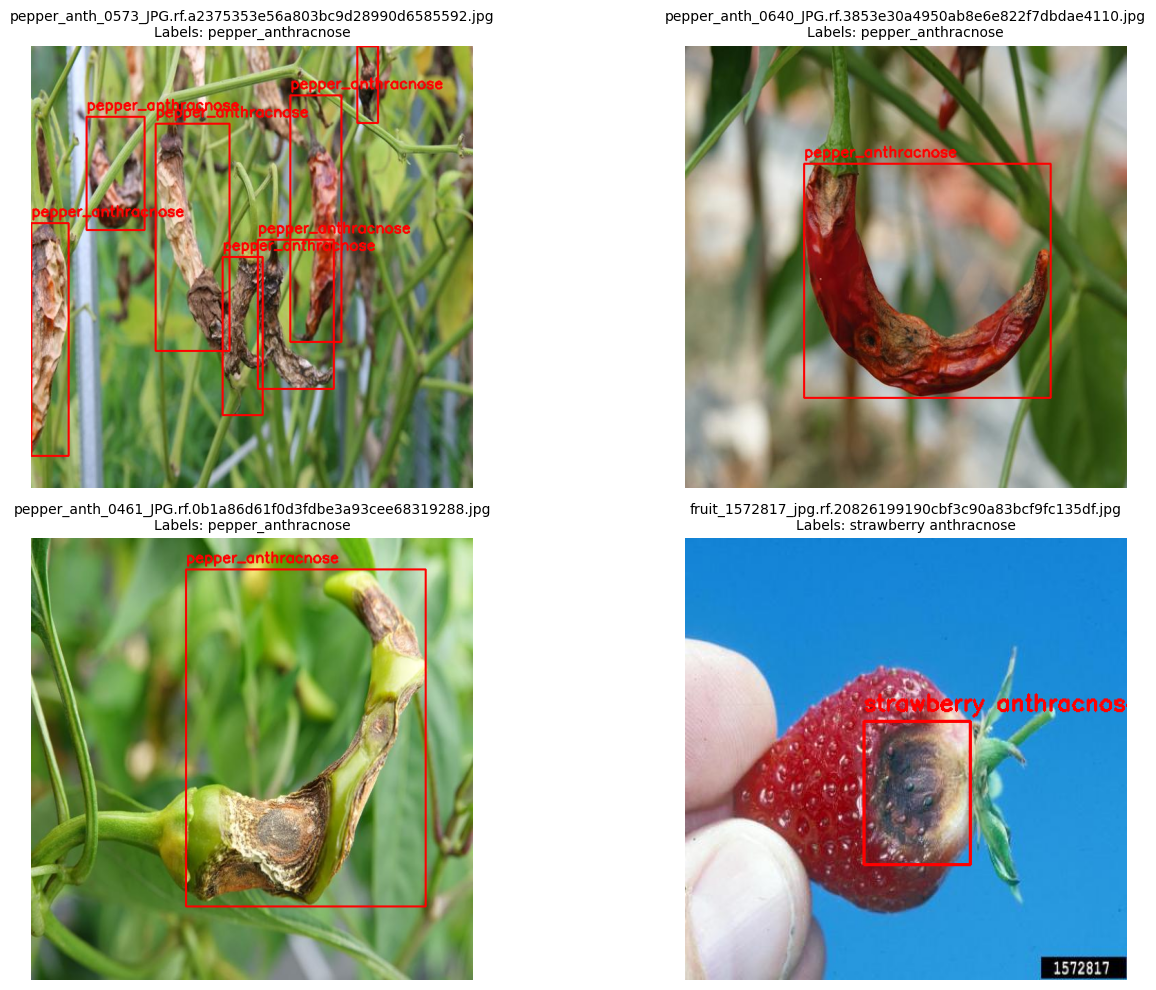

In [ ]:
plot_images(VALOR_DS, split='val')


### Visualisation Consommation (Fresh-Rotten)


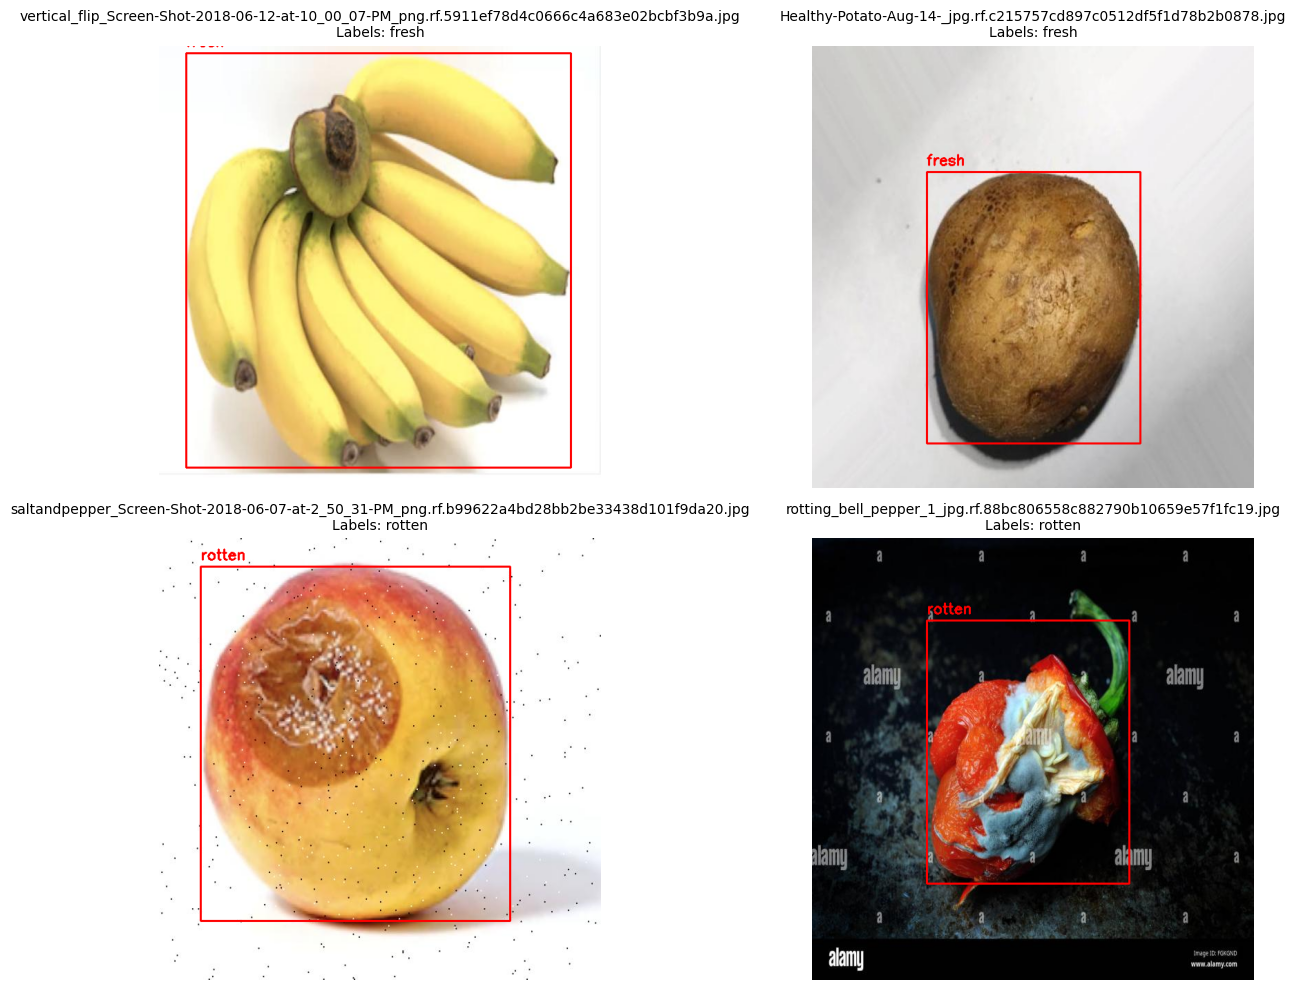

In [24]:
consumer_path = os.path.join("../" "data", "raw", "consumer", "Fresh-Rotten 1.v4i.yolo26")
plot_images(consumer_path, split='valid')

In [30]:
analyze_classes(consumer_path)

Analyzing train labels:  19%|█▉        | 540/2862 [00:00<00:00, 5393.82it/s]

Analyzing train labels: 100%|██████████| 2862/2862 [00:00<00:00, 4166.84it/s]


{'rotten': 5258, 'fresh': 9411}